# DeepISA tutorial

What does ISA do?
What files do you have for the analysis?

## Basic imports and data loading

Prepare the following files for the deepISA pipeline:

* Reference genome: [hg38](https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz)

* Jaspar: [JASPAR 2026](https://mencius.uio.no/JASPAR/JASPAR_TFBSs/2026/JASPAR2026_hg38.bb) is genome-wide predictions of TF binding sites in bigBed format for hundreds of TFs, based on high-quality TF Position Frequency Matrices. Other versions (JASPAR 2022, 2024) may cause compatibility issues.

* ReMap (optional): [ReMap 2022](https://remap.univ-amu.fr/storage/remap2022/hg38/MACS2/remap2022_nr_macs2_hg38_v1_0.bed.gz) is a curated atlas of 182 million DNA-TF binding peaks, derived from 8103 human ChIP-seq datasets, covering hundreds of TFs across hundreds of cell lines and tissues.

In [1]:
import os
import bioframe as bf
import pandas as pd
from loguru import logger

FASTA_PATH = "/maps/projects/ralab/people/pcr980/Resource/hg38.fa"
JASPAR_BB = "/maps/projects/ralab/people/pcr980/Resource/JASPAR/JASPAR2026_hg38.bb"
REMAP_BED = "/maps/projects/ralab/people/pcr980/Resource/ReMap2022/ReMap2022_K-562.bed"
CELL_FACET = "B_lymphoblastoid"
BW_DIR = "/maps/projects/ralab/data/projects/nucleiCAGEproject/0.External_resources/FANTOM5/pooled_bw"


## QuickStart, the fast track

regions_pos.bed comes containing randomly selected 1000 candidate regulatory regions with CAGE signal, for B_lymphoblastoid cell line. 

Subsetting regulatory regions aims to accelerate training for tutorial. The model performance is supposed to improve with full set of regulatory regions.

On output file names:
* "motif_": information about individual TF binding sites
* "tf_": TF features aggregated from all binding sites

In [2]:
# if you don't have a pretrained model:
from deepISA.utils import get_data_resource

bed_path = get_data_resource("regions_pos_with_count.csv")
df_regions = pd.read_csv(bed_path)
df_regions.head()

,chrom,start,end,target_reg
0,chr12,55725882,55726482,13.0
1,chr19,36028217,36028817,13.0
2,chr1,7403363,7403963,13.0
3,chr2,68062734,68063334,337.0
4,chr7,151632560,151633160,54.0


10:56:51 | INFO     | Logger initialized. All logs and errors redirected to: ./QuickStart_results/workflow.log


/maps/projects/ralab/people/pcr980/miniforge3/envs/genome_gpu/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


10:56:51 | INFO     | Using GPU 0: NVIDIA H100 NVL (93.09 GB)
10:56:51 | INFO     | Using device: cuda:0
10:56:51 | INFO     | Starting Training...
10:56:51 | INFO     | Compiling training data into ./QuickStart_results/Data/training_data.csv...
10:56:51 | INFO     | All 1000 regions already have the identical target length of 600 bp. Skipping resize.
10:56:51 | INFO     | Scenario 1: Using provided signal column 'target_reg'.
10:56:51 | INFO     | No class column provided. Inferring target_class (signal > 0).
10:56:51 | INFO     | Initial counts: 1000 positives, 0 negatives.
10:56:51 | INFO     | Sampling 1000 extra negatives from background pool.
10:56:51 | INFO     | Regions have variable lengths. Centering and resizing 1000 regions to 600 bp.
10:56:51 | INFO     | Saved training data to ./QuickStart_results/Data/training_data.csv
10:56:51 | INFO     | Initializing Trainer...
10:56:51 | INFO     | Using GPU 0: NVIDIA H100 NVL (93.09 GB)
10:56:51 | INFO     | Loading FASTA from /maps

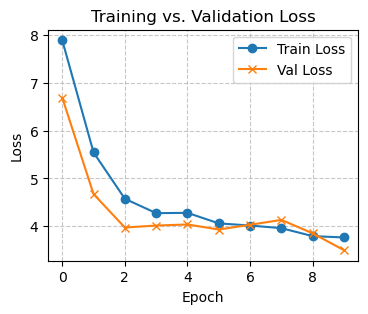

10:56:59 | INFO     | Using GPU 0: NVIDIA H100 NVL (93.09 GB)
10:56:59 | INFO     | Evaluating model on 600 samples...
10:56:59 | INFO     | Evaluation Complete | Pearson r: 0.6341 (p=8.65e-69)


In [3]:
# if you don't have a pretrained model:

from deepISA.quickstart import QuickStart

pipe = QuickStart(
    results_dir="./QuickStart_results",
    fasta_path=FASTA_PATH,
    df_regions=df_regions,
    target_reg_col="target_reg", # specify the column in df_regions that contains the signal, the regression prediction target
)

pipe.train()


In [ ]:
pipe.run_isa(
    jaspar_path=JASPAR_BB
)
pipe.aggregate_isa()
pipe.report() # Generate DeepCompAREs-stype plots demonstrating the cooperativity rules.

While `jaspar_path` is the only required argument for `.run_isa()`, providing a list of `expressed_tfs` is highly recommended for biological relevance. By passing a list of TFs known to be expressed in your specific cell line, the model filters out motifs of TFs that aren't present and therefore cannot be functional. We also provide function `get_expressed_tfs()` to estimate expressed TF list from the candidate regions and genome-wide bigwig signals. See section _____ for more information.

Variations of QuickStart usage:
* If you only have the regions and a bigwig file, but you haven't quantified it yourself, we can quantify it for you (also see section _____), just privide the bw_path in `.train()`.

* If you have a pretrained model already, just provide the model path, and we start from `.run_isa()`.

In [ ]:
# If you have a pretrained model:
pretrained_model_path = get_data_resource("model_blympho.pt") # This is a model trained on the all the candidate CREs of B_lymphoblastoid, so we can skip training and go straight to ISA.
pipe = QuickStart(
    results_dir="./QuickStart_pretrained",
    model_path=pretrained_model_path, # path to the pretrained model
    fasta_path=FASTA_PATH,
    df_regions=df_regions,
)

# Skip .train()
pipe.run_isa(jaspar_path=JASPAR_BB)
pipe.aggregate_isa()
pipe.report()

## Details of workflow: step by step

Let's disect the workflow that QuickStart wraps up.

In [4]:
# set up logger to save logs in the results directory
from deepISA.utils import setup_logger
from deepISA.modeling.preprocess import compile_training_data
from deepISA.utils import get_data_resource

RESULTS_DIR = "Step_by_step_res"
os.makedirs(RESULTS_DIR, exist_ok=True)

setup_logger(RESULTS_DIR)
logger.info("Starting deepISA tutorial")


09:36:46 | INFO     | Logger initialized. All logs and errors redirected to: Step_by_step_res/workflow.log
09:36:46 | INFO     | Starting deepISA tutorial


### 1. Prepare data for deep learning

This step uses function `compile_training_data()`. It takes in your BED file as a `pandas.DataFrame` and returns labeled data for downstream deep learning.

The input DataFrame must include the following column names:

* "chrom": chromosome identifier
* "start": start coordinate
* "end": end coordinate

Ensure that all intervals satisfy: end - start == target_input_length

Multiple preprocessing workflows are supported. You may either provide pre-quantified data (option 1), or use the built-in labeling function, simply by passing additional arguments to `compile_training_data()` (option 2).

#### Option 1: BED file with pre-quantified signals

Use this mode if your have already quantified the signals (e.g., TPM or read counts) for the candidate regions. The pipeline will automatically sample non-functional background regions to balance the dataset, so that number of positive and negative regions equalize.

These background regions are sampled genome-wide, excluding candidate Cis-Regulatory Elements ([cCREs](https://www.nature.com/articles/s41586-025-09909-9)), exons and the ENCODE blacklist.

Make sure that your quantified signals are not log-transformed, since compile_training_data() will automatically perform log transformation

In [3]:
# read an internal example file
df_pos = pd.read_csv(get_data_resource("regions_pos_with_count.csv"))
df_pos.head()

,chrom,start,end,target_reg
0,chr12,55725882,55726482,13.0
1,chr19,36028217,36028817,13.0
2,chr1,7403363,7403963,13.0
3,chr2,68062734,68063334,337.0
4,chr7,151632560,151633160,54.0


In [4]:
df_data = compile_training_data(
    df=df_pos, 
    seq_len=600, 
    target_reg_col="target_reg", # your column name for TPM/count/signal, not log transformed.
    outpath = os.path.join(RESULTS_DIR, "training_data.csv")
)

df_data.head() 

17:11:20 | INFO     | All 1000 regions already have the identical target length of 600 bp. Skipping resize.
17:11:20 | INFO     | Scenario 1: Using provided signal column 'target_reg'.
17:11:20 | INFO     | No class column provided. Inferring target_class (signal > 0).


17:11:20 | INFO     | Initial counts: 1000 positives, 0 negatives.
17:11:20 | INFO     | Sampling 1000 extra negatives from background pool.
17:11:20 | INFO     | Regions have variable lengths. Centering and resizing 1000 regions to 600 bp.
17:11:21 | INFO     | Saved training data to Step_by_step_res/training_data.csv


,chrom,start,end,target_reg,target_class
0,chr18,10716184,10716784,0.0,0.0
1,chr20,62937693,62938293,2329.0,1.0
2,chr7,145897560,145898160,0.0,0.0
3,chr19,11024900,11025500,15.0,1.0
4,chr4,140682613,140683213,0.0,0.0


Two additional columns are added by function `compile_training_data()`: 
* "target_reg": regression target, meaning the signal intensity before log transformation
* "target_class": classification target, 1 for positive regions (regulatory elements), 0 for negative regions.

#### Option 2: BED file + BigWig signal tracks

If you have genomic coordinates of regulatory elements, and want to quantify signals directly from BigWig files. The pipeline estimates a noise threshold from background regions to define the classification target.

Just pass a list of bigwig file paths to the optional parameter `bw_paths`.
  

#### Option 3: simply a bed file of positive regions
#TODO: to be implemented


### 2 Train convolutional neural network

This step uses function `train_model()`. It takes in the labeled data frame, performs train-val-test split, then train a exponentially dilated convolutional neural network. The main architecture highly resembles BPNet, but doesn't contain the per-base profile prediction for faster training.

Early stopping is enabled by default, so it is design to "overfit" the validation set. Use `evaluate_model()` to get the unbiased performance estimate.

By default, `rc_aug==True`, to apply reverse complement data augmentation. This is highly recommended for stable training, unless you are training on strand-aware data like single-stranded CAGE-Seq signals.

For hyperparameter tuning, `train_model()` will automatically save a "training_log.csv" to record the learning curve.

/maps/projects/ralab/people/pcr980/miniforge3/envs/genome_gpu/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


17:11:22 | INFO     | Using GPU 0: NVIDIA H100 NVL (93.09 GB)
17:11:22 | INFO     | Loading FASTA from /maps/projects/ralab/people/pcr980/Resource/hg38.fa
17:11:22 | INFO     | Extracting sequences from 2000 regions.
17:11:22 | INFO     | Filtered to 2000 valid sequences.
17:11:22 | INFO     | Writing 4000 samples to disk in chunks of size 8096.
17:11:22 | INFO     | Writing chunk 0/0 to disk
17:11:22 | INFO     | One hot encoded sequences saved to disk.
17:11:22 | INFO     | Splits created: Train=2800, Val=600, Test=600
17:11:27 | INFO     | 
Epoch 0 Summary:
Set        | Loss       | Accuracy   | Pearson R 
----------------------------------------------------
Train      | 7.6193     | -          | -         
Val        | 6.6962     | 0.4833     | 0.6422    

17:11:27 | INFO     | 
Epoch 1 Summary:
Set        | Loss       | Accuracy   | Pearson R 
----------------------------------------------------
Train      | 5.6690     | -          | -         
Val        | 6.1706     | 0.6883    

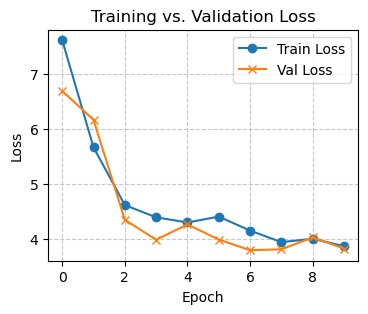

In [5]:

from deepISA.modeling.train import train_model

df_data = pd.read_csv(os.path.join(RESULTS_DIR, "training_data.csv"))

model, history, test_ds = train_model(
    df=df_data,
    fasta_path=FASTA_PATH, 
    model_dir=RESULTS_DIR,
    epochs=10    
)

# If you are satisfied with the data preprocessing but want to retrain the model
# just set use_cached_data=True

In [6]:
# To get real test performance, run:
from deepISA.modeling.predict import evaluate_model
test_r = evaluate_model(model, test_ds)
print(f"Final Test Pearson r: {test_r}")

17:11:29 | INFO     | Using GPU 0: NVIDIA H100 NVL (93.09 GB)
17:11:29 | INFO     | Evaluating model on 600 samples...
17:11:29 | INFO     | Evaluation Complete | Pearson r: 0.6929 (p=5.50e-87)
Final Test Pearson r: 0.692867636680603


### 3. Map motifs for all candidate regulatory regions with positive signal

This step uses function `map_motif()`. It takes in the candidate regulatory regions with positive signal, and returns all the motif locations according to [JASPAR 2026](https://mencius.uio.no/JASPAR/JASPAR_TFBSs/2026/JASPAR2026_hg38.bb) database, thresholded by motif matching score, for each regulatory region. 

The JASPAR matching score (range: 100-1000) quantifies how well a short DNA sequence aligns with a transcription factor motif from the JASPAR database, using a position weight matrix to compute a similarity score at each position. The default Jaspar score is 500, meaning the p-value of motif matching is 1e-5.

In [7]:
from deepISA.scoring.annotation import map_motifs

#TODO: write preprocess_remap(cell_type). 
motif_csv_path = map_motifs(
    regions_df=df_pos, 
    jaspar_path=JASPAR_BB,
    expressed_tfs=None, # set to None for tutorial, but providing expressed_tf_list is highly recommended for real analysis to reduce false positives.
    outpath=os.path.join(RESULTS_DIR,"motif_locs.csv"),
    score_thresh=500,
    remap_path=None # don't specify whether a TFBS is supported by ChIP-Seq due to lack of cell-type specific ChIP-Seq data in remap 
)

# read the mapped motif locations
df_motif_locs = pd.read_csv(os.path.join(RESULTS_DIR,"motif_locs.csv"))
df_motif_locs.head()

17:11:29 | INFO     | Starting motif mapping.
17:11:29 | INFO     | Processing region 0...


17:11:41 | INFO     | Complete. Output saved to: Step_by_step_res/motif_locs.csv


,chrom,start,end,tf,score,strand,region
0,chr12,55725912,55725927,ZNF418,500,+,chr12:55725882-55726482
1,chr12,55725939,55725958,RREB1,571,+,chr12:55725882-55726482
2,chr12,55726016,55726032,ZNF347,504,+,chr12:55725882-55726482
3,chr12,55726020,55726030,ZNF148,524,+,chr12:55725882-55726482
4,chr12,55726261,55726271,WT1,517,-,chr12:55725882-55726482



One way to reduce false positive of TF binding site is to retain only those with overlapping ChIP-Seq peak recorded in [ReMap 2022](https://remap2022.univ-amu.fr/) database. It is essentially a giant bed file containing genomic locations of ChIP-Seq peak for thousands of TFs in hundreds of cell lines. By setting `remap_path=YOUR_REMAP_PATH`, function `map_motif()` will return an additional column "remap_evidence" of boolean values, indicating whether each motif is supported by the ChIP-Seq peak of the same TF according to ReMap. Then you can subset manually to contain only the motifs supported by ChIP-Seq.

However, not all TFs expressed in each cell line have a corresponding ChIP-Seq experiment, thus subsetting by ReMap evidence risks losing valid TF binding sites simply due to lack of ChIP-Seq experiment recorded in ReMap.

We recommend a more lenient motif filtering strategy: filtering by TF gene expression level since only expressed TFs can exert influence. By passing `expressed_tfs=YOUR_EXPRESSED_TF_LIST`, function `map_motif()` will only return the motifs of TFs in the `expressed_tfs`.

In [8]:
from deepISA.scoring.infer_tf_expr import get_expressed_tfs

# Define the same BigWig tracks used for training
bw_paths = [
    f"{BW_DIR}/{CELL_FACET}.minus.bw", 
    f"{BW_DIR}/{CELL_FACET}.plus.bw"
]

# Infer the list of expressed TFs based on a noise threshold
expressed_tf_list = get_expressed_tfs(
    bw_paths=bw_paths, 
    percentile=99
)

len(expressed_tf_list)

17:11:41 | INFO     | Loading TF promoters from /maps/projects/ralab/people/pcr980/DeepCompare/deepISA/data/hg38_TF_promoters_500bp.bed...
17:11:41 | INFO     | Quantifying signal for 1620 TF promoters...
17:11:41 | INFO     | All 1620 regions already have the identical target length of 1000 bp. Skipping resize.
17:11:41 | INFO     | Processing BigWig: B_lymphoblastoid.minus.bw
17:11:42 | INFO     | Processing BigWig: B_lymphoblastoid.plus.bw
17:11:42 | INFO     | Estimating noise threshold from 50000 background regions...
17:11:42 | INFO     | Regions have variable lengths. Centering and resizing 50000 regions to 1000 bp.
17:11:42 | INFO     | All 50000 regions already have the identical target length of 1000 bp. Skipping resize.
17:11:42 | INFO     | Processing BigWig: B_lymphoblastoid.minus.bw
17:11:44 | INFO     | Processing BigWig: B_lymphoblastoid.plus.bw
17:11:46 | INFO     | Calculated noise threshold: 22.0000 (99th percentile)
17:11:46 | INFO     | Inferred 848 expressed TFs.


848

### 4. Run single ISA to quantify TF importance

This step first uses function `run_single_isa()`. It takes in a well-trained model and the filtered motif locations, and output the in silico ablation scores of all motifs directly to hard disk. This step is computation heavy, thus GPU is necessary here. 

Then we use function `calc_tf_importance()` to aggregate all the motif ISA scores for each TF. Aggregation methods include mean, median and signed Kolmogorov-Smirnov (KS) statistics. KS requires sufficient instances for accurate calculation, thus it produces a warning if fewer than 5 instances exist for a TF.

In [9]:
import torch
from deepISA.modeling.cnn import Conv
from deepISA.scoring.single_isa import run_single_isa, calc_tf_importance
from deepISA.utils import find_available_gpu

# 1. Load model, send to GPU if available
model=Conv()
model_path = f"{RESULTS_DIR}/model_best.pt"
model.load_state_dict(torch.load(model_path, weights_only=False))
device = find_available_gpu()

# 2. read the mapped motif locations
motif_locs=pd.read_csv(os.path.join(RESULTS_DIR, "motif_locs.csv"))

# 3. Compute Single-Motif ISA
run_single_isa(
    model=model, 
    fasta_path=FASTA_PATH,
    motif_locs=motif_locs,
    device=device,
    outpath=os.path.join(RESULTS_DIR, "motif_single_isa.csv"),
    batch_size=200  # Adjust based on your GPU memory, larger batch size will speed up the process but use more memory
)

17:11:47 | INFO     | Using GPU 0: NVIDIA H100 NVL (93.09 GB)
17:11:47 | INFO     | Single ISA for 20762 motifs.


17:11:49 | INFO     | Processed batch 1: 3879 motif importance saved.
17:11:52 | INFO     | Processed batch 2: 4397 motif importance saved.
17:11:55 | INFO     | Processed batch 3: 4248 motif importance saved.
17:11:58 | INFO     | Processed batch 4: 3875 motif importance saved.
17:12:01 | INFO     | Processed batch 5: 4363 motif importance saved.
17:12:01 | INFO     | Single ISA complete. Results saved to Step_by_step_res/motif_single_isa.csv


In [10]:
df_single_isa = pd.read_csv(os.path.join(RESULTS_DIR, "motif_single_isa.csv"))
df_single_isa.head()

,chrom,start,end,tf,score,strand,region,start_rel,end_rel,isa_t0
0,chr10,102400712,102400732,PRDM9,532,+,chr10:102400698-102401298,14,34,0.000244
1,chr10,102400733,102400748,ZFP14,514,+,chr10:102400698-102401298,35,50,0.012720
2,chr10,102400839,102400854,ZNF707,525,-,chr10:102400698-102401298,141,156,0.012152
3,chr10,102400841,102400855,ZNF530,535,+,chr10:102400698-102401298,143,157,0.012037
4,chr10,102400850,102400864,PLAG1,521,+,chr10:102400698-102401298,152,166,0.013254


In [11]:
# 4: aggregate single ISA
tf_importance = calc_tf_importance(os.path.join(RESULTS_DIR, "motif_single_isa.csv"))

# Save the final summary
tf_importance.to_csv(os.path.join(RESULTS_DIR, "tf_importance.csv"), index=False)

# 5. Visualize Top Drivers (Track 0: Regression/Expression)
print("Top 10 TFs by Expression Impact:")
display(tf_importance.sort_values("ks_isa_t0", ascending=False).head(10))

17:12:01 | INFO     | Calculating TF importance for tracks: ['isa_t0']


17:12:01 | WARNING  | Insufficient data for TF ATOH7 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF BHLHA15 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF BHLHE22 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF CUX1 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF DDIT3::CEBPA to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF DMBX1 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF DMRT1 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF DUXBL1 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF E2F2 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF E2F3 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF E2F4 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF EPAS1 to perform KS test.
17:12:01 | WARNING  | Insufficient data for TF ETV2::DRGX to perform KS test.
17:12:01 | WARNING  | Insufficient dat

,tf,count,mean_isa_t0,median_isa_t0,ks_isa_t0
165,HES7,22,0.110363,0.097578,0.485796
462,ZIC1,24,0.114046,0.057537,0.428696
164,HES6,7,0.045115,0.015364,0.426982
166,HEY1,18,0.087838,0.088235,0.418312
163,HES5,22,0.088038,0.090350,0.418312
465,ZIC5,26,0.112897,0.065666,0.412018
167,HEY2,13,0.078739,0.067849,0.410365
162,HES2,13,0.079839,0.067849,0.410365
582,ZNF836,12,0.056583,0.045521,0.400483
519,ZNF436,21,0.065823,0.047475,0.383393


### 5. Run combinatorial ISA for TF pair cooperativity

This step first uses function `run_combi_isa()`. It takes in a well-trained model, the filtered motif locations, and model receptive field. Then it performs combinatorial ISA for all motifs on same regulatory region within distance of the model receptive field. Models trained by deepISA package have attribute `.rf` for receptive field.

Then we use function `calc_coop_score()` to aggregate the raw combinatorial ISA results and obtain cooperativity score. Note, this aggregation can be performed on both TF-pair and TF level, by specifying `level=tf_pair`, or `level='tf_pair`. 

In the cooperativity score report, TF pairs are always alphabetically sorted and concatenated by "|".

In [4]:
from deepISA.scoring.combi_isa import run_combi_isa

# 1. Run the pairwise ablation
COMB_RESULTS_PATH = os.path.join(RESULTS_DIR, "motif_combi_isa.csv")

run_combi_isa(
    model=model,
    fasta_path=FASTA_PATH,
    motif_locs=motif_locs, 
    device=device,
    receptive_field=model.rf,
    outpath=COMB_RESULTS_PATH
)

df_combi_isa = pd.read_csv(COMB_RESULTS_PATH)
df_combi_isa.head()


,region,tf1,tf2,start1,end1,start2,end2,distance,isa1_t0,isa2_t0,isa_both_t0,interaction_t0
0,chr12:55725882-55726482,ZNF418,RREB1,30,45,57,76,27,0.001184,0.039220,0.038966,0.001437
1,chr12:55725882-55726482,ZNF418,ZNF347,30,45,134,150,104,0.001184,0.063350,0.063990,0.000544
2,chr12:55725882-55726482,ZNF418,ZNF148,30,45,138,148,108,0.001184,0.044888,0.045745,0.000326
3,chr12:55725882-55726482,RREB1,ZNF347,57,76,134,150,77,0.039220,0.063350,0.087015,0.015555
4,chr12:55725882-55726482,RREB1,ZNF148,57,76,138,148,81,0.039220,0.044888,0.072511,0.011596


In [5]:
from deepISA.scoring.combi_isa import  calc_coop_score

outpath_pair = os.path.join(RESULTS_DIR, "coop_tf_pair.csv")
calc_coop_score(df_combi_isa, outpath_pair, level="tf_pair")

outpath_tf = os.path.join(RESULTS_DIR, "coop_tf.csv")
calc_coop_score(df_combi_isa, outpath_tf, level="tf")


17:17:06 | INFO     | Cooperativity stats saved to Step_by_step_res/coop_tf_pair.csv
17:17:11 | INFO     | Cooperativity stats saved to Step_by_step_res/coop_tf.csv


### 6. Plot results

deepISA package provide deepCompARE style analysis and plots, for reproducibility and sanity check.

In [5]:
# load result data
import os
import pandas as pd
RESULTS_DIR = "Step_by_step_res"
df_raw_combi = pd.read_csv(os.path.join(RESULTS_DIR, "motif_combi_isa.csv"))
df_coop_pair = pd.read_csv(os.path.join(RESULTS_DIR, "coop_tf_pair.csv"))
df_coop_tf = pd.read_csv(os.path.join(RESULTS_DIR, "coop_tf.csv"))


#### Observation 1: interaction decays along distance

<Axes: title={'center': 'Null Distribution\n(100-255bp)'}, xlabel='Interaction', ylabel='Density\n(cbrt scale)'>

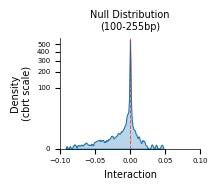

In [6]:
from deepISA.plotting.interaction import (
    plot_null,
    plot_interaction_decay, 
)

plot_null(df_raw_combi)

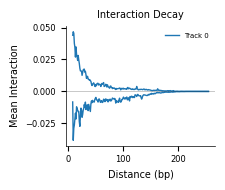

In [7]:
plot_interaction_decay(df_raw_combi)

#### Observation 2: TF-pair level cooperativity 

<Axes: xlabel='Cooperativity score', ylabel='Frequency'>

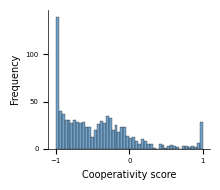

In [5]:
from deepISA.plotting.cooperativity import (
    hist_coop_score,
    heatmap_coop_score,
    plot_motif_distance_by_category
)

hist_coop_score(df_coop_pair)

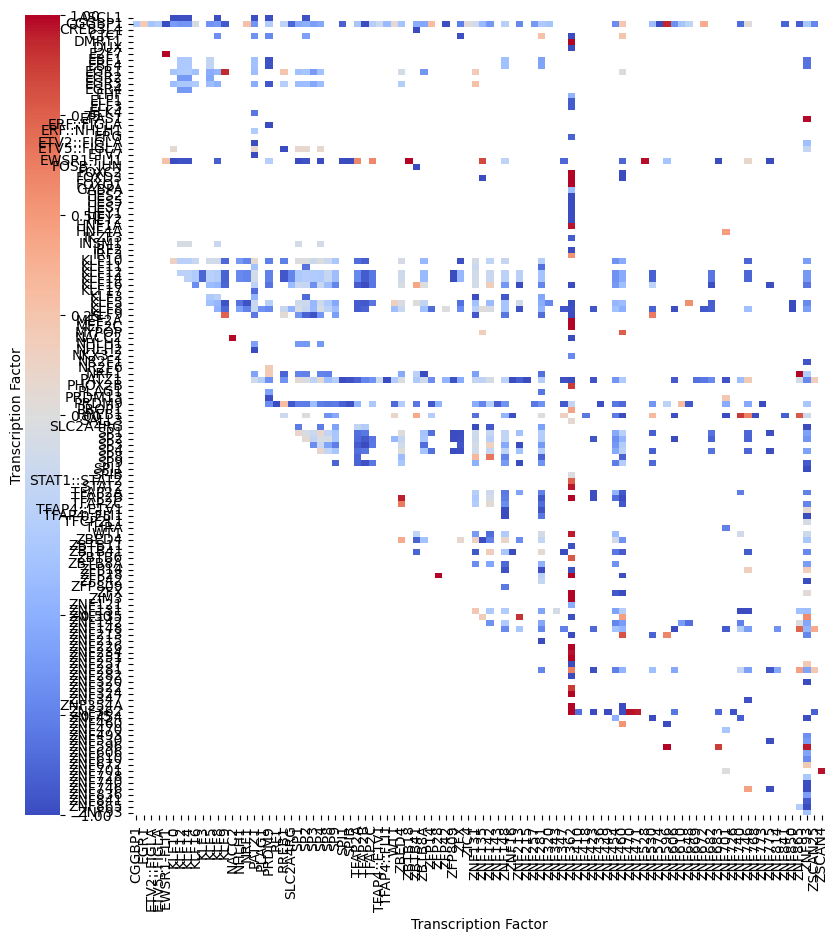

In [6]:
# Height for labels can be set based on max frequency
heatmap_coop_score(df_coop_pair)

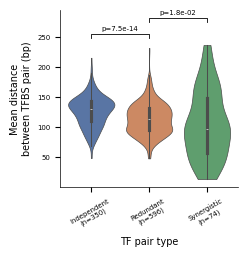

In [7]:
plot_motif_distance_by_category(df_coop_pair)

#### Observation 3: TF level cooperativity

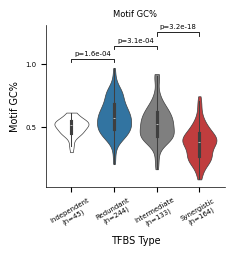

In [8]:
from deepISA.plotting.tf import (
    plot_motif_gc_by_coop,
    plot_coop_vs_importance
)

df_coop_tf = pd.read_csv(os.path.join(RESULTS_DIR, "coop_tf.csv"))
plot_motif_gc_by_coop(df_coop_tf)

In [9]:
# Plot cooperativity score vs importance score 
df_importance = pd.read_csv(os.path.join(RESULTS_DIR, "tf_importance.csv"))
plot_coop_vs_importance(df_coop_tf, df_importance)

TypeError: plot_coop_vs_importance() missing 2 required positional arguments: 'x_col' and 'y_col'

### 7. Explore association with external data

Tell user dimers "::" are removed from PPI validation.
Only for human

#### Observation 4: TF family behavior

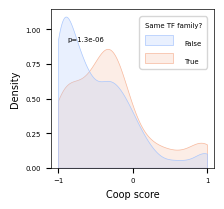

In [10]:
from deepISA.validating.tf_family import (
    plot_coop_by_tf_pair_family,
    plot_coop_by_dbd,
    plot_intra_family_coop_score
)

df_res=plot_coop_by_tf_pair_family(df_coop_pair)

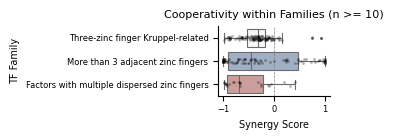

In [11]:
df_res=plot_intra_family_coop_score(df_coop_pair)

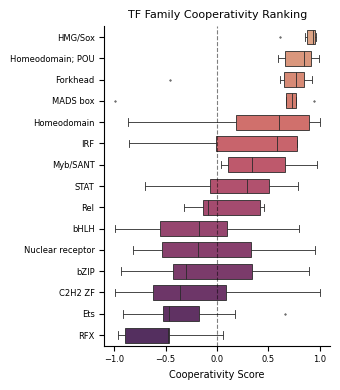

In [12]:
df_res=plot_coop_by_dbd(df_coop_tf)

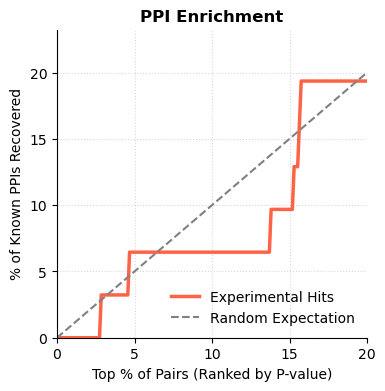

In [13]:
from deepISA.validating.tf_pair_ppi import (
    plot_ppi_enrichment,
    validate_cofactor_recruitment
)


df_res = plot_ppi_enrichment(df_coop_pair)

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


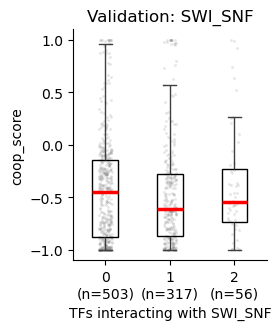

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


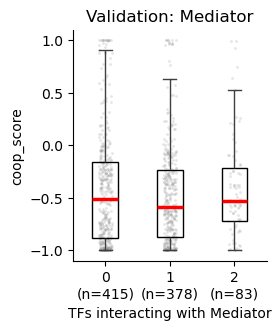

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


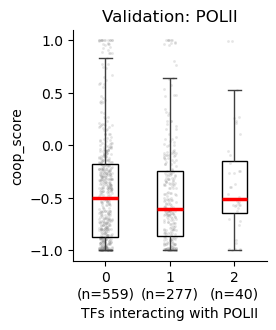

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


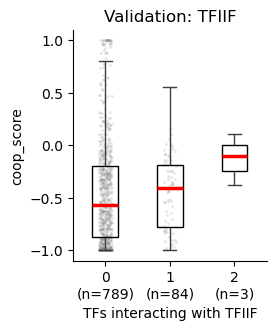

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


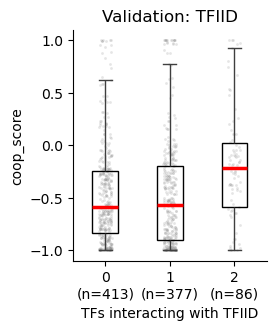

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


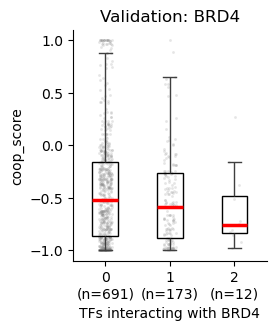

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


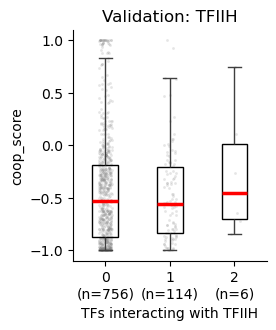

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


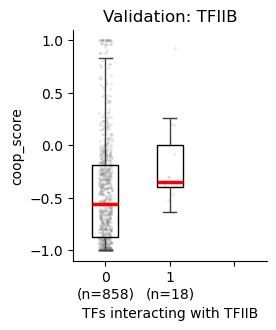

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/validating/tf_pair_ppi.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


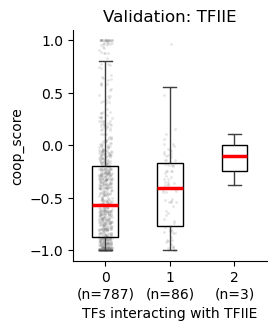

In [15]:
# Cooperativity between TF pairs of same family
df_res=validate_cofactor_recruitment(df_coop_pair)

Validate with TF functions: gini index and known TF functional categories.

USFs Median: -0.419 (n=21)
Pioneers Median: -0.296 (n=21)
Context-only Median: 0.766 (n=15)


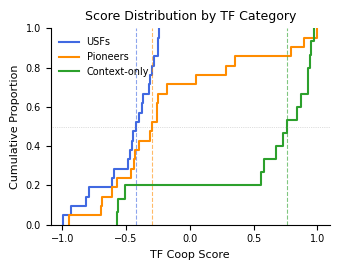

In [17]:
from deepISA.validating.tf_function import (
    plot_usf_pfs,
    plot_cell_specificity
)

plot_usf_pfs(df_coop_tf)

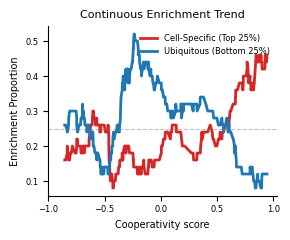

In [18]:
plot_cell_specificity(df_coop_tf)